In [1]:
import importlib
import sys
import numpy as np
import pandas as pd

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')

In [2]:
# Preprocess for BPIC20 DD:
# Remove role suffix in activity names (e.g., "[Declaration SUBMITTED by EMPLOYEE]" -> "[Declaration SUBMITTED]")
# Remove exact duplicate rows

"""

import re

event_log_location = '../../../../../../data/data/DomesticDeclarations.csv'
df_raw = pd.read_csv(event_log_location)
activity_col = "concept:name"

def _strip_by_suffix(value):
    if pd.isna(value):
        return value
    s = str(value)
    if s == "EOS":
        return s
    # If the activity is bracketed, remove " by ..." before the closing bracket
    s = re.sub(r"\s+by\s+[^\]]+(?=\])", "", s)
    # General fallback: remove " by ..." at end of string
    s = re.sub(r"\s+by\s+.*$", "", s)
    return s

df_raw[activity_col] = df_raw[activity_col].map(_strip_by_suffix)

root, ext = os.path.splitext(event_log_location)
cleaned_event_log_location = f"{root}_cleaned{ext or '.csv'}"
df_raw.to_csv(cleaned_event_log_location, index=False)

# Use the cleaned log for the rest of this notebook
print("Wrote cleaned log to:", cleaned_event_log_location)

"""

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1638783/2747318592.py:20: SyntaxWarning: invalid escape sequence '\s'
  s = re.sub(r"\s+by\s+[^\]]+(?=\])", "", s)


'\n\nimport re\n\nevent_log_location = \'../../../../../../data/data/DomesticDeclarations.csv\'\ndf_raw = pd.read_csv(event_log_location)\nactivity_col = "concept:name"\n\ndef _strip_by_suffix(value):\n    if pd.isna(value):\n        return value\n    s = str(value)\n    if s == "EOS":\n        return s\n    # If the activity is bracketed, remove " by ..." before the closing bracket\n    s = re.sub(r"\\s+by\\s+[^\\]]+(?=\\])", "", s)\n    # General fallback: remove " by ..." at end of string\n    s = re.sub(r"\\s+by\\s+.*$", "", s)\n    return s\n\ndf_raw[activity_col] = df_raw[activity_col].map(_strip_by_suffix)\n\nroot, ext = os.path.splitext(event_log_location)\ncleaned_event_log_location = f"{root}_cleaned{ext or \'.csv\'}"\ndf_raw.to_csv(cleaned_event_log_location, index=False)\n\n# Use the cleaned log for the rest of this notebook\nprint("Wrote cleaned log to:", cleaned_event_log_location)\n\n'

In [3]:

import data_processing.labeling_encoding
importlib.reload(data_processing.labeling_encoding)
from data_processing.labeling_encoding import PrefixesDataFrameLoader, EventLogLoader

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = '../../../../../../data/data/DomesticDeclarations_cleaned.csv'

result_name = 'bpic20_dd_all'

# dynamic categorical attributes
cat_dynamic = ['concept:name',
               'org:resource',
               'org:role'
              ]

# static categorical attributes
cat_static = ['case:BudgetNumber',
              'case:DeclarationNumber'
             ]

# dynamic numerical attributes
num_dynamic = ['case_elapsed_time',
               'event_elapsed_time',
               'day_in_week',
               'seconds_in_day',
               ]

# dynamic log-normal encoded numerical attributes 
num_dyn_log = []

# static numeric attributes
num_static = ['case:Amount']

min_suffix_size = 5

# 20% test size:
test_validation_size = 0.2

event_log_properties = {# case id
                        'case_name' : 'case:concept:name',
                        # activity
                        'concept_name' : 'concept:name',
                        # time values and computaitons
                        'timestamp_name' : 'time:timestamp',                       
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # train and test split
                        'train_validation_size' : 0.15,
                        'test_validation_size' : test_validation_size,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## Create dataframes of prefixes

In [4]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [5]:
# output if necessary the raw dataframe: dynamic are lists, static values
raw_data = pref_adopt_dataframe.get_raw_dataframe()
raw_data

,case:concept:name,concept:name,org:resource,org:role,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:BudgetNumber,case:DeclarationNumber,case:Amount
0,declaration 86791,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, SYSTEM, SYSTEM]","[EMPLOYEE, SUPERVISOR, UNDEFINED, UNDEFINED]","[0.0, 5878.0, 85494.0, 286892.0]","[nan, 5878.0, 79616.0, 201398.0]","[0, 0, 1, 3]","[35390, 41268, 34484, 63082]",budget 86566,declaration number 86792,26.851205
1,declaration 86795,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, PRE_APPROVER, SUPERVISOR, UNDEFINED...","[0.0, 3801787.0, 3880111.0, 4851671.0, 5468685.0]","[nan, 3801787.0, 78324.0, 971560.0, 617014.0]","[0, 2, 3, 0, 0]","[37574, 37761, 29685, 50845, 63059]",budget 86566,declaration number 86796,182.464172
2,declaration 86800,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, PRE_APPROVER, SUPERVISOR, UNDEFINED...","[0.0, 2101517.0, 2656891.0, 2695602.0, 3046721.0]","[nan, 2101517.0, 555374.0, 38711.0, 351119.0]","[0, 3, 3, 3, 0]","[40413, 68330, 18904, 57615, 63134]",budget 86566,declaration number 86801,320.646137
3,declaration 86731,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, SYSTEM, SYSTEM]","[EMPLOYEE, SUPERVISOR, UNDEFINED, UNDEFINED]","[0.0, 783.0, 184378.0, 626874.0]","[nan, 783.0, 183595.0, 442496.0]","[0, 0, 2, 0]","[41060, 41843, 52638, 63134]",budget 86566,declaration number 86732,113.862047
4,declaration 86735,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, SYSTEM, SYSTEM]","[EMPLOYEE, SUPERVISOR, UNDEFINED, UNDEFINED]","[0.0, 412.0, 184012.0, 626508.0]","[nan, 412.0, 183600.0, 442496.0]","[0, 0, 2, 0]","[41426, 41838, 52638, 63134]",budget 86566,declaration number 86736,134.404169
...,...,...,...,...,...,...,...,...,...,...,...
10495,declaration 138337,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, STA...","[EMPLOYEE, ADMINISTRATION, BUDGET OWNER, SUPER...","[0.0, 88.0, 939975.0, 1513830.0, 1527604.0, 17...","[nan, 88.0, 939887.0, 573855.0, 13774.0, 20317...","[4, 4, 1, 1, 1, 3]","[60313, 60401, 49888, 18943, 32717, 63095]",budget 86566,declaration number 138338,6.360310
10496,declaration 138343,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, STA...","[EMPLOYEE, ADMINISTRATION, BUDGET OWNER, SUPER...","[0.0, 69.0, 939895.0, 1513734.0, 1527506.0, 17...","[nan, 69.0, 939826.0, 573839.0, 13772.0, 20318...","[4, 4, 1, 1, 1, 3]","[60409, 60478, 49904, 18943, 32715, 63095]",budget 86566,declaration number 138344,6.360310
10497,declaration 138349,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFIN...","[0.0, 1012.0, 931490.0, 997140.0, 1116767.0]","[nan, 1012.0, 930478.0, 65650.0, 119627.0]","[4, 4, 1, 2, 3]","[69501, 70513, 50591, 29841, 63068]",budget 86566,declaration number 138350,446.667698
10498,declaration 138354,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFIN...","[0.0, 347.0, 930213.0, 995698.0, 1115309.0]","[nan, 347.0, 929866.0, 65485.0, 119611.0]","[4, 4, 1, 2, 3]","[70959, 71306, 50772, 29857, 63068]",budget 86566,declaration number 138355,214.205763


In [6]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,org:role,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:BudgetNumber,case:DeclarationNumber,case:Amount
0,declaration 86795,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[0.0],[37574.0],budget 86566,declaration number 86796,182.464172
1,declaration 86795,2,"[Declaration SUBMITTED, Declaration APPROVED]","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, PRE_APPROVER]","[0.0, 3801787.0]","[nan, 3801787.0]","[0.0, 2.0]","[37574.0, 37761.0]",budget 86566,declaration number 86796,182.464172
2,declaration 86795,3,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, PRE_APPROVER, SUPERVISOR]","[0.0, 3801787.0, 3880111.0]","[nan, 3801787.0, 78324.0]","[0.0, 2.0, 3.0]","[37574.0, 37761.0, 29685.0]",budget 86566,declaration number 86796,182.464172
3,declaration 86795,4,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, PRE_APPROVER, SUPERVISOR, UNDEFINED]","[0.0, 3801787.0, 3880111.0, 4851671.0]","[nan, 3801787.0, 78324.0, 971560.0]","[0.0, 2.0, 3.0, 0.0]","[37574.0, 37761.0, 29685.0, 50845.0]",budget 86566,declaration number 86796,182.464172
4,declaration 86795,5,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, PRE_APPROVER, SUPERVISOR, UNDEFINED...","[0.0, 3801787.0, 3880111.0, 4851671.0, 5468685.0]","[nan, 3801787.0, 78324.0, 971560.0, 617014.0]","[0.0, 2.0, 3.0, 0.0, 0.0]","[37574.0, 37761.0, 29685.0, 50845.0, 63059.0]",budget 86566,declaration number 86796,182.464172
...,...,...,...,...,...,...,...,...,...,...,...,...
36658,declaration 138359,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[5.0],[64214.0],budget 86566,declaration number 138360,190.404576
36659,declaration 138359,2,"[Declaration SUBMITTED, Declaration APPROVED]","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 359.0]","[nan, 359.0]","[5.0, 5.0]","[64214.0, 64573.0]",budget 86566,declaration number 138360,190.404576
36660,declaration 138359,3,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, SUPERVISOR]","[0.0, 359.0, 399938.0]","[nan, 359.0, 399579.0]","[5.0, 5.0, 3.0]","[64214.0, 64573.0, 32152.0]",budget 86566,declaration number 138360,190.404576
36661,declaration 138359,4,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFINED]","[0.0, 359.0, 399938.0, 829814.0]","[nan, 359.0, 399579.0, 429876.0]","[5.0, 5.0, 3.0, 1.0]","[64214.0, 64573.0, 32152.0, 30028.0]",budget 86566,declaration number 138360,190.404576


In [7]:
train_pref_df.to_csv('../../../../data/BPIC20_DD/raw_data/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [8]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,org:role,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:BudgetNumber,case:DeclarationNumber,case:Amount
0,declaration 86805,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[0.0],[42047.0],budget 86566,declaration number 86806,443.585163
1,declaration 86805,2,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, SUPERVISOR]","[0.0, 36.0]","[nan, 36.0]","[0.0, 0.0]","[42047.0, 42083.0]",budget 86566,declaration number 86806,443.585163
2,declaration 86805,3,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, SYSTEM]","[EMPLOYEE, SUPERVISOR, UNDEFINED]","[0.0, 36.0, 1378244.0]","[nan, 36.0, 1378208.0]","[0.0, 0.0, 2.0]","[42047.0, 42083.0, 37891.0]",budget 86566,declaration number 86806,443.585163
3,declaration 86805,4,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, SYSTEM, SYSTEM]","[EMPLOYEE, SUPERVISOR, UNDEFINED, UNDEFINED]","[0.0, 36.0, 1378244.0, 1835448.0]","[nan, 36.0, 1378208.0, 457204.0]","[0.0, 0.0, 2.0, 0.0]","[42047.0, 42083.0, 37891.0, 63095.0]",budget 86566,declaration number 86806,443.585163
4,declaration 86820,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[1.0],[36292.0],budget 86566,declaration number 86821,79.192885
...,...,...,...,...,...,...,...,...,...,...,...,...
8542,declaration 138305,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[2.0],[79906.0],budget 86566,declaration number 138306,35.232129
8543,declaration 138305,2,"[Declaration SUBMITTED, Declaration APPROVED]","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 3.0]","[nan, 3.0]","[2.0, 2.0]","[79906.0, 79909.0]",budget 86566,declaration number 138306,35.232129
8544,declaration 138305,3,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, SUPERVISOR]","[0.0, 3.0, 564217.0]","[nan, 3.0, 564214.0]","[2.0, 2.0, 2.0]","[79906.0, 79909.0, 39323.0]",budget 86566,declaration number 138306,35.232129
8545,declaration 138305,4,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFINED]","[0.0, 3.0, 564217.0, 988964.0]","[nan, 3.0, 564214.0, 424747.0]","[2.0, 2.0, 2.0, 0.0]","[79906.0, 79909.0, 39323.0, 32070.0]",budget 86566,declaration number 138306,35.232129


In [9]:
val_pref_df.to_csv('../../../../data/BPIC20_DD/raw_data/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [10]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,org:role,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:BudgetNumber,case:DeclarationNumber,case:Amount
0,declaration 86791,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[0.0],[35390.0],budget 86566,declaration number 86792,26.851205
1,declaration 86791,2,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, SUPERVISOR]","[0.0, 5878.0]","[nan, 5878.0]","[0.0, 0.0]","[35390.0, 41268.0]",budget 86566,declaration number 86792,26.851205
2,declaration 86791,3,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, SYSTEM]","[EMPLOYEE, SUPERVISOR, UNDEFINED]","[0.0, 5878.0, 85494.0]","[nan, 5878.0, 79616.0]","[0.0, 0.0, 1.0]","[35390.0, 41268.0, 34484.0]",budget 86566,declaration number 86792,26.851205
3,declaration 86791,4,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, SYSTEM, SYSTEM]","[EMPLOYEE, SUPERVISOR, UNDEFINED, UNDEFINED]","[0.0, 5878.0, 85494.0, 286892.0]","[nan, 5878.0, 79616.0, 201398.0]","[0.0, 0.0, 1.0, 3.0]","[35390.0, 41268.0, 34484.0, 63082.0]",budget 86566,declaration number 86792,26.851205
4,declaration 86716,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[0.0],[54605.0],budget 86566,declaration number 86717,22.765521
...,...,...,...,...,...,...,...,...,...,...,...,...
11222,declaration 138331,2,"[Declaration SUBMITTED, Declaration APPROVED]","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 907.0]","[nan, 907.0]","[4.0, 4.0]","[59270.0, 60177.0]",budget 86566,declaration number 138332,161.048342
11223,declaration 138331,3,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, BUDGET OWNER]","[0.0, 907.0, 863655.0]","[nan, 907.0, 862748.0]","[4.0, 4.0, 0.0]","[59270.0, 60177.0, 58925.0]",budget 86566,declaration number 138332,161.048342
11224,declaration 138331,4,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, STA...","[EMPLOYEE, ADMINISTRATION, BUDGET OWNER, SUPER...","[0.0, 907.0, 863655.0, 941264.0]","[nan, 907.0, 862748.0, 77609.0]","[4.0, 4.0, 0.0, 1.0]","[59270.0, 60177.0, 58925.0, 50134.0]",budget 86566,declaration number 138332,161.048342
11225,declaration 138331,5,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, STA...","[EMPLOYEE, ADMINISTRATION, BUDGET OWNER, SUPER...","[0.0, 907.0, 863655.0, 941264.0, 1007441.0]","[nan, 907.0, 862748.0, 77609.0, 66177.0]","[4.0, 4.0, 0.0, 1.0, 2.0]","[59270.0, 60177.0, 58925.0, 50134.0, 29911.0]",budget 86566,declaration number 138332,161.048342


In [11]:
test_pref_df.to_csv('../../../../data/BPIC20_DD/raw_data/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## Optional: Compute Petri Net replay markings of prefixes 

In [12]:
# Optional set list of ids the petri net should be executed:
unique_list_train = train_pref_df["case:concept:name"].dropna().unique().tolist()
unique_list_val = val_pref_df["case:concept:name"].dropna().unique().tolist()

case_ids = list(dict.fromkeys(unique_list_train + unique_list_val))

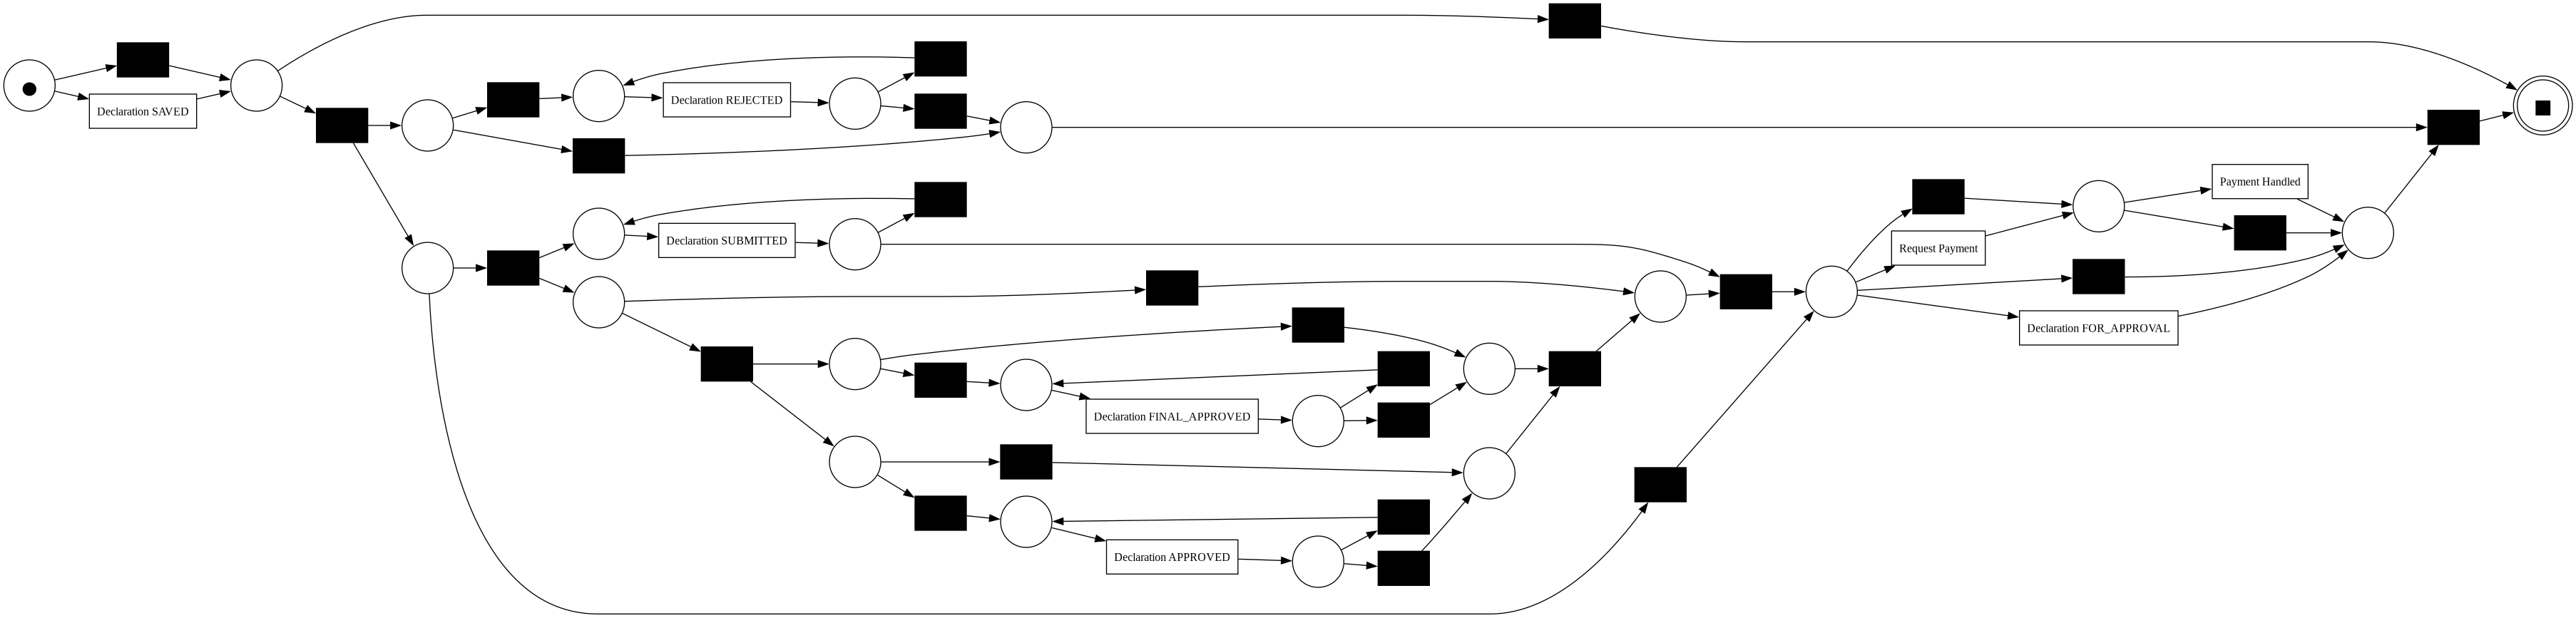

In [13]:
# Calculate and store markings:
import os
import pickle
import data_processing.petri_net_replay_markings
importlib.reload(data_processing.petri_net_replay_markings)
from data_processing.petri_net_replay_markings import InductiveMiner

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="case:concept:name", activity_col="concept:name", timestamp_col="time:timestamp", resource_col="org:resource")
store_loc_file_path = '../../../../data/BPIC20_DD/Petri_net/bpic20_dd.png'
net, im, fm = miner.discover_petri_net(visulaize=True,
                                       case_ids=case_ids,
                                       store_loc_file_path=store_loc_file_path)

# store discovered petri net objects next to the PNG
pkl_path = os.path.splitext(store_loc_file_path)[0] + '.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump((net, im, fm), f)

## Store "normal" tensor-datasets

In [14]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [15]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# save dataset 
torch.save(train_set, '../../../../data/BPIC20_DD/tensor_data/normal/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/6825 [00:00<?, ?it/s]

org:resource:   0%|          | 0/6825 [00:00<?, ?it/s]

org:role:   0%|          | 0/6825 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

...

event_elapsed_time:   0%|          | 0/6825 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/6825 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/6825 [00:00<?, ?it/s]

static categorical:   0%|          | 0/36663 [00:00<?, ?it/s]

static continuous:   0%|          | 0/36663 [00:00<?, ?it/s]

In [16]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)

print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())

print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())

print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())

if isinstance(train_set.decision_data, torch.Tensor):
    print("Decision data tensor: ", train_set.decision_data.size())
else:
    print("Decision data: ", len(train_set.decision_data))
    print("Decision data: ", len(train_set.decision_data[0]) if len(train_set.decision_data) > 0 else 0)

# print(train_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 10, {'Declaration APPROVED': 1, 'Declaration FINAL_APPROVED': 2, 'Declaration FOR_APPROVAL': 3, 'Declaration REJECTED': 4, 'Declaration SAVED': 5, 'Declaration SUBMITTED': 6, 'EOS': 7, 'Payment Handled': 8, 'Request Payment': 9}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('case:BudgetNumber', 2, {'budget 86566': 1}), ('case:DeclarationNumber', 6516, {'UNKNOWN': 1, 'declaration number 100001': 2, 'declaration number 100006': 3, 'declaration number 100011': 4, 'declaration number 100016': 5, 'declaration numbe

In [17]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# save dataset 
torch.save(val_set, '../../../../data/BPIC20_DD/tensor_data/normal/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/1575 [00:00<?, ?it/s]

org:resource:   0%|          | 0/1575 [00:00<?, ?it/s]

org:role:   0%|          | 0/1575 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

...

event_elapsed_time:   0%|          | 0/1575 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/1575 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/1575 [00:00<?, ?it/s]

static categorical:   0%|          | 0/8547 [00:00<?, ?it/s]

static continuous:   0%|          | 0/8547 [00:00<?, ?it/s]

In [18]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)

print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())

print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())

print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())

# print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
# print(val_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 10, {'Declaration APPROVED': 1, 'Declaration FINAL_APPROVED': 2, 'Declaration FOR_APPROVAL': 3, 'Declaration REJECTED': 4, 'Declaration SAVED': 5, 'Declaration SUBMITTED': 6, 'EOS': 7, 'Payment Handled': 8, 'Request Payment': 9}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('case:BudgetNumber', 2, {'budget 86566': 1}), ('case:DeclarationNumber', 6516, {'UNKNOWN': 1, 'declaration number 100001': 2, 'declaration number 100006': 3, 'declaration number 100011': 4, 'declaration number 100016': 5, 'declaration numbe

In [19]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# save dataset 
torch.save(test_set, '../../../../data/BPIC20_DD/tensor_data/normal/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/2100 [00:00<?, ?it/s]

org:resource:   0%|          | 0/2100 [00:00<?, ?it/s]

org:role:   0%|          | 0/2100 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

...

event_elapsed_time:   0%|          | 0/2100 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/2100 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/2100 [00:00<?, ?it/s]

static categorical:   0%|          | 0/11227 [00:00<?, ?it/s]

static continuous:   0%|          | 0/11227 [00:00<?, ?it/s]

In [20]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)

print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
# print("Dynamic categorical tensor examples: ", test_set.categorical_tensors[0][10:55])
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())

print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())

print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print("Zero padds: ", test_set.zero_padding[35:41])
# print("EOS padds: ", test_set.eos_padding[35:41])

# print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
# print(test_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 10, {'Declaration APPROVED': 1, 'Declaration FINAL_APPROVED': 2, 'Declaration FOR_APPROVAL': 3, 'Declaration REJECTED': 4, 'Declaration SAVED': 5, 'Declaration SUBMITTED': 6, 'EOS': 7, 'Payment Handled': 8, 'Request Payment': 9}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('case:BudgetNumber', 2, {'budget 86566': 1}), ('case:DeclarationNumber', 6516, {'UNKNOWN': 1, 'declaration number 100001': 2, 'declaration number 100006': 3, 'declaration number 100011': 4, 'declaration number 100016': 5, 'declaration numbe